# Agentic GraphRAG with LangGraph

A Corrective RAG (CRAG) agent that retrieves from a knowledge graph, grades relevance, and rewrites queries when needed.

In [2]:
import sys, os
sys.path.append('..')
from dotenv import load_dotenv
load_dotenv()

import operator
from typing import Annotated, List, Optional, TypedDict, Literal

from langchain_core.messages import AnyMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from loguru import logger
import numpy as np

from utils import validate, get_neo4j_client, get_general_llm, get_strong_llm, get_embeddings
validate()

In [3]:
client = get_neo4j_client()
client.verify_connectivity()

node_count = client.get_node_count()
if node_count == 0:
    print("WARNING: Graph is empty!")
else:
    print(f"Graph has {node_count} nodes and {client.get_relationship_count()} relationships.")

2026-06-17 08:43:55.005 | SUCCESS  | utils.neo4j_client:verify_connectivity:30 - Connected to Neo4j at neo4j+s://c621105e.databases.neo4j.io


Graph has 506 nodes and 1290 relationships.


## 1. Agent State

The state is a 'conveyor belt' — each node reads what it needs and writes its updates.

In [4]:
class GraphRAGState(TypedDict):
    """State for the Corrective RAG workflow over a knowledge graph.

    Fields:
        messages:           Chat message history (Annotated reducer — appends).
        question:           Current question (may be rewritten by the rewriter node).
        original_question:  Preserved original user question.
        entities:           Extracted entity names from the question.
        documents:          Retrieved context documents (Annotated reducer — appends).
        route:              Router decision: 'drug_interaction' | 'general_medical' | 'chitchat'
        grade:              Grader decision: 'relevant' | 'not_relevant'
        retry_count:        Number of rewrite-retrieve-grade cycles completed.
        final_answer:       The synthesised response text.
    """
    messages: Annotated[list[AnyMessage], add_messages]
    question: str
    original_question: str
    entities: List[str]
    documents: Annotated[List[str], operator.add]
    route: str
    grade: str
    retry_count: int
    final_answer: Optional[str]

## 2. Prompts & Schemas

In [6]:
# --- Load all prompts from central config ---
from utils.prompts import (
    ROUTER_SYSTEM_PROMPT,
    GRADER_SYSTEM_PROMPT,
    GRADER_HUMAN_PROMPT,
    REWRITER_SYSTEM_PROMPT,
    REWRITER_HUMAN_PROMPT,
    GENERATOR_SYSTEM_PROMPT,
    GENERATOR_HUMAN_PROMPT,
    GENERAL_MEDICAL_PROMPT,
    CHITCHAT_RESPONSE,
)

# Structured Output Schemas

class RouteDecision(BaseModel):
    destination: Literal["drug_interaction", "general_medical", "chitchat"] = Field(
        ..., description="The category to route the question to."
    )

class GradeDecision(BaseModel):
    binary_score: str = Field(description="Relevance score: 'yes' or 'no'")
    reasoning: str = Field(default="", description="Brief explanation of the grade")


## 3. Entity Resolution & Graph Retriever

These two classes power the retrieval pipeline: resolve user terms to graph entities, then traverse the graph with Cypher.

In [7]:
from dataclasses import dataclass

# Configuration
from utils import get_config
_params = get_config()
FUZZY_MATCH_THRESHOLD = _params.get("retrieval", {}).get("fuzzy_match_threshold", 0.8)

@dataclass
class ResolvedEntity:
    """A resolved entity match from the knowledge graph."""
    canonical_name: str
    label: str
    score: float
    match_type: str  # "exact", "fuzzy", "semantic"


class ExtractedQueryEntities(BaseModel):
    """Entities extracted from a natural language question."""
    entities: List[str] = Field(
        ..., description="List of drug, condition, or medical entity names from the question"
    )

In [8]:
# --- Load prompt from central config ---
from utils.prompts import ENTITY_EXTRACTION_PROMPT


class EntityResolver:
    """Resolve user query terms to canonical graph entities.

    Three-tier matching strategy:
      1. Exact (case-insensitive) — O(1) via Cypher index
      2. Fuzzy (CONTAINS) — handles partial matches
      3. Semantic (embedding cosine similarity) — handles synonyms & aliases
    """

    def __init__(self, client, embeddings=None):
        self._client = client
        self._embeddings = embeddings
        self._name_cache: Optional[dict] = None
        self._embedding_cache: Optional[dict] = None

    # ── Entity Extraction from Question ──────────────────

    def extract_entities_from_question(self, question: str, llm=None) -> List[str]:
        """Use LLM to extract entity names from a natural language question."""
        if llm is None:
            llm = get_general_llm()

        structured_llm = llm.with_structured_output(ExtractedQueryEntities)
        prompt = ChatPromptTemplate.from_messages([
            ("system", ENTITY_EXTRACTION_PROMPT),
            ("human", "{question}"),
        ])
        chain = prompt | structured_llm
        result = chain.invoke({"question": question})
        logger.info(f"Extracted entities: {result.entities}")
        return result.entities

    # ── Resolution ───────────────────────────────────────

    def resolve(self, query_entity: str, label: Optional[str] = None) -> List[ResolvedEntity]:
        """Resolve a query term to canonical graph entities.

        Tries exact -> fuzzy -> semantic matching.
        """
        results = []

        # Tier 1: Exact match (case-insensitive)
        exact = self._exact_match(query_entity, label)
        if exact:
            return exact

        # Tier 2: Fuzzy match (CONTAINS)
        fuzzy = self._fuzzy_match(query_entity, label)
        if fuzzy:
            return fuzzy

        # Tier 3: Semantic match (embedding similarity)
        if self._embeddings:
            semantic = self._semantic_match(query_entity, label)
            if semantic:
                return semantic

        logger.warning(f"No match found for entity: '{query_entity}'")
        return results

    def resolve_all(self, entities: List[str]) -> List[ResolvedEntity]:
        """Resolve a list of entities, returning the best match for each."""
        resolved = []
        for entity in entities:
            matches = self.resolve(entity)
            if matches:
                resolved.append(matches[0])  # Best match
        return resolved

    # ── Tier 1: Exact Match ──────────────────────────────

    def _exact_match(self, query: str, label: Optional[str] = None) -> List[ResolvedEntity]:
        """Case-insensitive exact name match."""
        if label:
            cypher = f"""
                MATCH (n:`{label}`)
                WHERE toLower(n.name) = toLower($name)
                RETURN n.name AS name, labels(n) AS labels
                LIMIT 5
            """
        else:
            cypher = """
                MATCH (n)
                WHERE toLower(n.name) = toLower($name)
                RETURN n.name AS name, labels(n) AS labels
                LIMIT 5
            """
        rows = self._client.query(cypher, {"name": query})
        return [
            ResolvedEntity(
                canonical_name=r["name"],
                label=r["labels"][0] if r["labels"] else "Unknown",
                score=1.0,
                match_type="exact",
            )
            for r in rows
        ]

    # ── Tier 2: Fuzzy Match ──────────────────────────────

    def _fuzzy_match(self, query: str, label: Optional[str] = None) -> List[ResolvedEntity]:
        """Partial string matching using CONTAINS and alias search."""
        if label:
            cypher = f"""
                MATCH (n:`{label}`)
                WHERE toLower(n.name) CONTAINS toLower($name)
                   OR any(alias IN coalesce(n.aliases, []) WHERE toLower(alias) CONTAINS toLower($name))
                RETURN n.name AS name, labels(n) AS labels
                LIMIT 5
            """
        else:
            cypher = """
                MATCH (n)
                WHERE toLower(n.name) CONTAINS toLower($name)
                   OR any(alias IN coalesce(n.aliases, []) WHERE toLower(alias) CONTAINS toLower($name))
                RETURN n.name AS name, labels(n) AS labels
                LIMIT 5
            """
        rows = self._client.query(cypher, {"name": query})
        return [
            ResolvedEntity(
                canonical_name=r["name"],
                label=r["labels"][0] if r["labels"] else "Unknown",
                score=0.8,
                match_type="fuzzy",
            )
            for r in rows
        ]

    # ── Tier 3: Semantic Match ───────────────────────────

    def _semantic_match(
        self, query: str, label: Optional[str] = None, top_k: int = 3
    ) -> List[ResolvedEntity]:
        """Embedding cosine similarity against cached node names."""
        if self._embedding_cache is None:
            self._build_embedding_cache()

        if not self._embedding_cache:
            return []

        query_emb = np.array(self._embeddings.embed_query(query))

        scored = []
        for name, (emb, lbl) in self._embedding_cache.items():
            if label and lbl != label:
                continue
            sim = float(np.dot(query_emb, emb) / (np.linalg.norm(query_emb) * np.linalg.norm(emb) + 1e-10))
            if sim >= FUZZY_MATCH_THRESHOLD:
                scored.append((name, lbl, sim))

        scored.sort(key=lambda x: x[2], reverse=True)
        return [
            ResolvedEntity(
                canonical_name=name,
                label=lbl,
                score=sim,
                match_type="semantic",
            )
            for name, lbl, sim in scored[:top_k]
        ]

    def _build_embedding_cache(self):
        """Build in-memory cache of node name embeddings."""
        logger.info("Building entity embedding cache...")
        rows = self._client.query(
            "MATCH (n) WHERE n.name IS NOT NULL RETURN n.name AS name, labels(n) AS labels"
        )
        if not rows:
            self._embedding_cache = {}
            return

        names = [r["name"] for r in rows]
        labels_list = [r["labels"][0] if r["labels"] else "Unknown" for r in rows]

        embeddings = self._embeddings.embed_documents(names)
        self._embedding_cache = {
            name: (np.array(emb), lbl)
            for name, emb, lbl in zip(names, embeddings, labels_list)
        }
        logger.info(f"Cached embeddings for {len(self._embedding_cache)} entities")


In [9]:
from utils import get_config
_params = get_config()
RETRIEVAL_MAX_HOPS = _params.get("retrieval", {}).get("max_hops", 2)
RETRIEVAL_TOP_K = _params.get("retrieval", {}).get("top_k", 5)
AGENT_MAX_RETRIES = _params.get("agent", {}).get("max_retries", 2)


class GraphRetriever:
    """Retrieve context from the knowledge graph using Cypher queries.

    Supports:
      - Single-hop: direct relationships for an entity
      - Multi-hop: variable-length path traversal (1..N hops)
      - Drug interaction: direct + shared side effects + same class
      - End-to-end: extract entities -> resolve -> retrieve -> format
    """

    def __init__(self, client, entity_resolver: EntityResolver):
        self._client = client
        self._resolver = entity_resolver

    # ── Single-Hop Retrieval ────────────────────────────

    def retrieve_single_hop(
        self, entity: str, rel_types: Optional[List[str]] = None
    ) -> List[dict]:
        """Get all direct relationships for an entity (1 hop)."""
        if rel_types:
            type_filter = " OR ".join(f"type(r) = '{rt}'" for rt in rel_types)
            cypher = f"""
                MATCH (n)-[r]->(m)
                WHERE n.name = $name AND ({type_filter})
                RETURN n.name AS source, labels(n) AS source_labels,
                       type(r) AS rel_type, properties(r) AS rel_props,
                       m.name AS target, labels(m) AS target_labels
                UNION
                MATCH (m)-[r]->(n)
                WHERE n.name = $name AND ({type_filter})
                RETURN m.name AS source, labels(m) AS source_labels,
                       type(r) AS rel_type, properties(r) AS rel_props,
                       n.name AS target, labels(n) AS target_labels
            """
        else:
            cypher = """
                MATCH (n)-[r]->(m)
                WHERE n.name = $name
                RETURN n.name AS source, labels(n) AS source_labels,
                       type(r) AS rel_type, properties(r) AS rel_props,
                       m.name AS target, labels(m) AS target_labels
                UNION
                MATCH (m)-[r]->(n)
                WHERE n.name = $name
                RETURN m.name AS source, labels(m) AS source_labels,
                       type(r) AS rel_type, properties(r) AS rel_props,
                       n.name AS target, labels(n) AS target_labels
            """
        return self._client.query(cypher, {"name": entity})

    # ── Multi-Hop Retrieval ─────────────────────────────

    def retrieve_multi_hop(
        self, entity: str, hops: int = RETRIEVAL_MAX_HOPS
    ) -> List[dict]:
        """Get relationships within N hops of an entity (variable-length path)."""
        cypher = f"""
            MATCH path = (n)-[*1..{hops}]-(m)
            WHERE n.name = $name AND n <> m
            WITH path, m,
                 [rel IN relationships(path) | type(rel)] AS rel_types,
                 [node IN nodes(path) | node.name] AS node_names
            RETURN node_names, rel_types,
                   m.name AS endpoint, labels(m) AS endpoint_labels,
                   length(path) AS path_length
            LIMIT $limit
        """
        return self._client.query(cypher, {"name": entity, "limit": RETRIEVAL_TOP_K * 2})

    # ── Drug Interaction Query ──────────────────────────

    def retrieve_interaction(self, drug_a: str, drug_b: str) -> List[dict]:
        """Find direct and indirect interactions between two drugs."""
        results = []

        # Direct interaction
        direct = self._client.query(
            """
            MATCH (a:Drug)-[r:INTERACTS_WITH]-(b:Drug)
            WHERE a.name = $a AND b.name = $b
            RETURN a.name AS drug_a, b.name AS drug_b,
                   r.severity AS severity, r.mechanism AS mechanism,
                   r.effect AS effect, r.recommendation AS recommendation
            """,
            {"a": drug_a, "b": drug_b},
        )
        for r in direct:
            r["interaction_type"] = "direct"
        results.extend(direct)

        # Shared side effects
        shared_se = self._client.query(
            """
            MATCH (a:Drug)-[:CAUSES_SIDE_EFFECT]->(se:SideEffect)<-[:CAUSES_SIDE_EFFECT]-(b:Drug)
            WHERE a.name = $a AND b.name = $b
            RETURN a.name AS drug_a, b.name AS drug_b, collect(se.name) AS shared_side_effects
            """,
            {"a": drug_a, "b": drug_b},
        )
        for r in shared_se:
            r["interaction_type"] = "shared_side_effects"
        results.extend(shared_se)

        # Same drug class
        same_class = self._client.query(
            """
            MATCH (a:Drug)-[:BELONGS_TO_CLASS]->(dc:DrugClass)<-[:BELONGS_TO_CLASS]-(b:Drug)
            WHERE a.name = $a AND b.name = $b
            RETURN a.name AS drug_a, b.name AS drug_b, collect(dc.name) AS shared_classes
            """,
            {"a": drug_a, "b": drug_b},
        )
        for r in same_class:
            r["interaction_type"] = "same_class"
        results.extend(same_class)

        return results

    # ── End-to-End Retrieval ────────────────────────────

    def retrieve_for_question(
        self, question: str, llm=None, max_hops: int = RETRIEVAL_MAX_HOPS
    ) -> List[Document]:
        """Full pipeline: extract entities -> resolve -> retrieve -> format as Documents.

        This is the main entry point used by the CRAG agent.
        """
        # 1. Extract entities from question
        raw_entities = self._resolver.extract_entities_from_question(question, llm=llm)

        if not raw_entities:
            logger.warning("No entities extracted from question")
            return [Document(page_content="No medical entities found in the question.")]

        # 2. Resolve entities to canonical names
        resolved = self._resolver.resolve_all(raw_entities)
        if not resolved:
            logger.warning(f"Could not resolve entities: {raw_entities}")
            return [Document(
                page_content=f"Could not find entities {raw_entities} in the knowledge graph."
            )]

        logger.info(f"Resolved entities: {[(r.canonical_name, r.match_type) for r in resolved]}")

        # 3. Retrieve context
        all_results = []
        entity_names = [r.canonical_name for r in resolved]

        # If 2 drugs -> check interaction
        drug_entities = [r for r in resolved if r.label == "Drug"]
        if len(drug_entities) >= 2:
            ix_results = self.retrieve_interaction(
                drug_entities[0].canonical_name,
                drug_entities[1].canonical_name,
            )
            all_results.extend(ix_results)

        # Single/multi-hop for each entity
        for entity_name in entity_names:
            single = self.retrieve_single_hop(entity_name)
            all_results.extend(single)

            if max_hops > 1:
                multi = self.retrieve_multi_hop(entity_name, hops=max_hops)
                all_results.extend(multi)

        # 4. Format as Documents
        if not all_results:
            return [Document(
                page_content=f"No graph data found for entities: {entity_names}"
            )]

        documents = []
        seen = set()
        for result in all_results:
            text = self._format_result(result)
            if text not in seen:
                seen.add(text)
                documents.append(Document(
                    page_content=text,
                    metadata={"source": "knowledge_graph"},
                ))

        logger.info(f"Retrieved {len(documents)} unique context documents")
        return documents[:RETRIEVAL_TOP_K * 3]  # Limit total documents

    # ── Formatting ──────────────────────────────────────

    @staticmethod
    def _format_result(result: dict) -> str:
        """Convert a Cypher result row into a readable context string."""
        parts = []

        if "source" in result and "target" in result and "rel_type" in result:
            parts.append(f"{result['source']} --[{result['rel_type']}]--> {result['target']}")
            props = result.get("rel_props", {})
            if props:
                for k, v in props.items():
                    if v and k != "source":
                        parts.append(f"  {k}: {v}")

        elif "drug_a" in result and "drug_b" in result:
            ix_type = result.get("interaction_type", "")
            parts.append(f"Interaction between {result['drug_a']} and {result['drug_b']} ({ix_type})")
            for key in ["severity", "mechanism", "effect", "recommendation",
                        "shared_side_effects", "shared_classes"]:
                if key in result and result[key]:
                    parts.append(f"  {key}: {result[key]}")

        elif "node_names" in result:
            path_str = " -> ".join(str(n) for n in result["node_names"])
            rels_str = " -> ".join(str(r) for r in result.get("rel_types", []))
            parts.append(f"Path: {path_str}")
            parts.append(f"  via: {rels_str}")

        else:
            parts.append(str(result))

        return "\n".join(parts)

In [12]:
resolver = EntityResolver(client, embeddings=get_embeddings())
retriever = GraphRetriever(client, resolver)

# Quick test
docs = retriever.retrieve_for_question("What drugs interact with Warfari?", llm=get_general_llm())
print(f"Retrieved {len(docs)} documents:")
for doc in docs[:3]:
    print(f"  {doc.page_content[:100]}...")

2026-06-17 08:56:46.700 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['Warfari']
2026-06-17 08:56:48.505 | INFO     | __main__:retrieve_for_question:151 - Resolved entities: [('Warfarin', 'fuzzy')]
2026-06-17 08:56:49.036 | INFO     | __main__:retrieve_for_question:192 - Retrieved 54 unique context documents


Retrieved 15 documents:
  Warfarin --[INTERACTS_WITH]--> Aspirin
  severity: Major
  effect: Significantly increased risk of b...
  Warfarin --[INTERACTS_WITH]--> Ibuprofen
  severity: Major
  effect: Increased risk of gastrointesti...
  Warfarin --[INTERACTS_WITH]--> Naproxen
  severity: Major
  effect: Increased bleeding risk, particu...


## 4. Multi-Hop Queries — The Graph Advantage

This is where knowledge graphs shine over vector search. Let's see multi-hop traversal in action.

In [14]:
# 1-HOP: Direct interactions
print("=== 1-HOP: Direct interactions with Warfarin ===")
results = client.query("""
    MATCH (d:Drug {name: 'Warfarin'})-[r:INTERACTS_WITH]-(other:Drug)
    RETURN other.name AS drug, r.severity AS severity
    LIMIT 5
""")
for r in results:
    print(f"  {r['drug']} (severity: {r['severity']})")

# 2-HOP: What drug classes do Warfarin's interacting drugs belong to?
print("\n=== 2-HOP: Drug classes of drugs that interact with Warfarin ===")
results = client.query("""
    MATCH (d:Drug {name: 'Warfarin'})-[:INTERACTS_WITH]-(other:Drug)-[:BELONGS_TO_CLASS]->(dc:DrugClass)
    RETURN other.name AS drug, dc.name AS drug_class
    LIMIT 5
""")
for r in results:
    print(f"  {r['drug']} belongs to class: {r['drug_class']}")

# CROSS-TYPE: Drugs sharing side effects with Warfarin
print("\n=== CROSS-TYPE: Drugs sharing side effects with Warfarin ===")
results = client.query("""
    MATCH (d:Drug {name: 'Warfarin'})-[:CAUSES_SIDE_EFFECT]->(se:SideEffect)<-[:CAUSES_SIDE_EFFECT]-(other:Drug)
    WHERE d <> other
    RETURN se.name AS side_effect, collect(other.name) AS other_drugs
    LIMIT 5
""")
for r in results:
    print(f"  Shared side effect '{r['side_effect']}' with: {r['other_drugs']}")

=== 1-HOP: Direct interactions with Warfarin ===


  Aspirin (severity: Major)
  Ibuprofen (severity: Major)
  Naproxen (severity: Major)
  Celecoxib (severity: Moderate)
  Clopidogrel (severity: Major)

=== 2-HOP: Drug classes of drugs that interact with Warfarin ===
  Aspirin belongs to class: NSAID
  Ibuprofen belongs to class: NSAID
  Naproxen belongs to class: NSAID
  Celecoxib belongs to class: NSAID
  Clopidogrel belongs to class: Antiplatelet

=== CROSS-TYPE: Drugs sharing side effects with Warfarin ===
  Shared side effect 'Bruising' with: ['Aspirin', 'Rivaroxaban', 'Apixaban', 'Clopidogrel', 'Prasugrel']
  Shared side effect 'Nausea' with: ['Aspirin', 'Rivaroxaban', 'Apixaban', 'Dabigatran', 'Prasugrel', 'Venlafaxine', 'Duloxetine', 'Fluoxetine', 'Sertraline', 'Citalopram', 'Escitalopram', 'Rosuvastatin', 'Pravastatin', 'Omeprazole', 'Esomeprazole', 'Pantoprazole', 'Lansoprazole', 'Amoxicillin', 'Azithromycin', 'Ciprofloxacin', 'Metronidazole', 'Erythromycin', 'Trimethoprim', 'Metformin', 'Glipizide', 'Morphine', 'Codeine', '

## 5. CRAG Agent — All Nodes

The Corrective RAG pattern: Router -> Retrieve -> Grade -> (Rewrite loop) -> Generate.

We define all 6 node functions in one cell.

In [15]:
def router_node(state: GraphRAGState) -> dict:
    logger.info("--- ROUTER ---")
    llm = get_general_llm().with_structured_output(RouteDecision)
    prompt = ChatPromptTemplate.from_messages([
        ("system", ROUTER_SYSTEM_PROMPT),
        ("human", "{question}"),
    ])
    chain = prompt | llm
    result = chain.invoke({"question": state["question"]})
    logger.info(f"   Routed to: {result.destination}")
    return {"route": result.destination, "retry_count": 0}


def graph_retriever_node(state: GraphRAGState) -> dict:
    logger.info("--- GRAPH RETRIEVER ---")
    documents = retriever.retrieve_for_question(state["question"], llm=get_general_llm())
    doc_texts = [doc.page_content for doc in documents]
    logger.info(f"   Retrieved {len(doc_texts)} documents")
    return {"documents": doc_texts}


def grader_node(state: GraphRAGState) -> dict:
    logger.info("--- GRADER ---")
    llm = get_general_llm().with_structured_output(GradeDecision)
    prompt = ChatPromptTemplate.from_messages([
        ("system", GRADER_SYSTEM_PROMPT),
        ("human", GRADER_HUMAN_PROMPT),
    ])
    chain = prompt | llm
    context = "\n\n".join(state["documents"]) if state["documents"] else "No documents retrieved."
    result = chain.invoke({"context": context, "question": state["question"]})
    grade = "relevant" if result.binary_score.lower() == "yes" else "not_relevant"
    logger.info(f"   Grade: {grade} ({result.reasoning})")
    return {"grade": grade}


def rewriter_node(state: GraphRAGState) -> dict:
    logger.info("--- REWRITER ---")
    llm = get_general_llm()
    prompt = ChatPromptTemplate.from_messages([
        ("system", REWRITER_SYSTEM_PROMPT),
        ("human", REWRITER_HUMAN_PROMPT),
    ])
    chain = prompt | llm
    result = chain.invoke({"question": state["question"]})
    new_question = result.content.strip()
    new_retry = state.get("retry_count", 0) + 1
    logger.info(f"   Rewritten: {new_question} (retry {new_retry})")
    return {"question": new_question, "retry_count": new_retry, "documents": []}


def generator_node(state: GraphRAGState) -> dict:
    logger.info("--- GENERATOR ---")
    llm = get_general_llm()
    prompt = ChatPromptTemplate.from_messages([
        ("system", GENERATOR_SYSTEM_PROMPT),
        ("human", GENERATOR_HUMAN_PROMPT),
    ])
    chain = prompt | llm
    context = "\n\n".join(state["documents"]) if state["documents"] else "No context available."
    result = chain.invoke({"context": context, "question": state["original_question"]})
    logger.info("   Generated answer")
    return {"messages": [AIMessage(content=result.content)], "final_answer": result.content}


def general_chat_node(state: GraphRAGState) -> dict:
    logger.info("--- GENERAL CHAT ---")
    route = state.get("route", "chitchat")
    if route == "chitchat":
        answer = CHITCHAT_RESPONSE
    else:
        llm = get_general_llm()
        prompt = ChatPromptTemplate.from_messages([
            ("system", GENERAL_MEDICAL_PROMPT),
            ("human", "{question}"),
        ])
        chain = prompt | llm
        result = chain.invoke({"question": state["question"]})
        answer = result.content
    return {"messages": [AIMessage(content=answer)], "final_answer": answer}


## 6. Conditional Edges & LangGraph Assembly

In [16]:
def route_from_router(state: GraphRAGState) -> str:
    route = state.get("route", "chitchat")
    if route == "drug_interaction":
        return "graph_retriever"
    return "general_chat"

def route_from_grader(state: GraphRAGState) -> str:
    if state.get("grade") == "relevant":
        return "generator"
    elif state.get("retry_count", 0) >= AGENT_MAX_RETRIES:
        logger.warning(f"Max retries ({AGENT_MAX_RETRIES}) reached.")
        return "generator"
    return "rewriter"

workflow = StateGraph(GraphRAGState)

# Add nodes
workflow.add_node("router", router_node)
workflow.add_node("graph_retriever", graph_retriever_node)
workflow.add_node("grader", grader_node)
workflow.add_node("rewriter", rewriter_node)
workflow.add_node("generator", generator_node)
workflow.add_node("general_chat", general_chat_node)

# Entry point
workflow.set_entry_point("router")

# Edges
workflow.add_conditional_edges("router", route_from_router, {
    "graph_retriever": "graph_retriever",
    "general_chat": "general_chat",
})
workflow.add_edge("graph_retriever", "grader")
workflow.add_conditional_edges("grader", route_from_grader, {
    "generator": "generator",
    "rewriter": "rewriter",
})
workflow.add_edge("rewriter", "graph_retriever")
workflow.add_edge("generator", END)
workflow.add_edge("general_chat", END)

# Compile
app = workflow.compile()

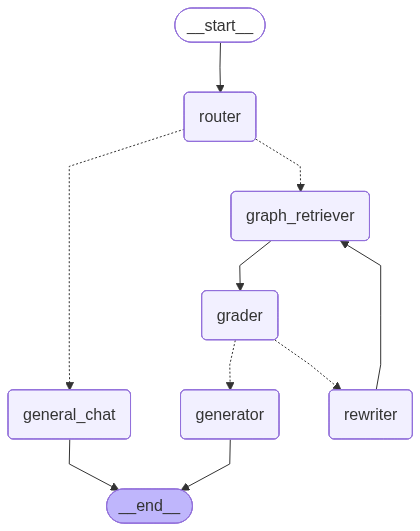

In [17]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 7. Test the Agent

Run queries through the full CRAG pipeline.

In [18]:
def run_query(app, question):
    inputs = {
        "messages": [],
        "question": question,
        "original_question": question,
        "entities": [],
        "documents": [],
        "route": "",
        "grade": "",
        "retry_count": 0,
        "final_answer": None,
    }
    result = app.invoke(inputs)
    return result.get("final_answer", "No answer generated.")

# Test 1: Drug interaction
print("=" * 60)
print("Q: Does Warfarin interact with Aspirin?")
print("=" * 60)
answer = run_query(app, "Does Warfarin interact with Aspirin?")
print(f"\nAnswer:\n{answer}")

2026-06-17 09:01:24.709 | INFO     | __main__:router_node:2 - --- ROUTER ---


Q: Does Warfarin interact with Aspirin?


2026-06-17 09:01:26.291 | INFO     | __main__:router_node:10 -    Routed to: drug_interaction
2026-06-17 09:01:26.321 | INFO     | __main__:graph_retriever_node:15 - --- GRAPH RETRIEVER ---
2026-06-17 09:01:27.285 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['Warfarin', 'Aspirin']
2026-06-17 09:01:27.878 | INFO     | __main__:retrieve_for_question:151 - Resolved entities: [('Warfarin', 'exact'), ('Aspirin', 'exact')]
2026-06-17 09:01:29.235 | INFO     | __main__:retrieve_for_question:192 - Retrieved 96 unique context documents
2026-06-17 09:01:29.239 | INFO     | __main__:graph_retriever_node:18 -    Retrieved 15 documents
2026-06-17 09:01:29.246 | INFO     | __main__:grader_node:23 - --- GRADER ---
2026-06-17 09:01:30.768 | INFO     | __main__:grader_node:33 -    Grade: relevant (The retrieved context documents provide detailed information about the interaction between Warfarin and Aspirin, including the severity, mechanism, effects, and recommendatio


Answer:
Yes, Warfarin interacts with Aspirin.

### Interaction Details:
- **Severity**: Major
- **Mechanism**: 
  - Warfarin inhibits vitamin K-dependent clotting factors, while Aspirin irreversibly inhibits platelet aggregation via COX-1 inhibition. 
  - Additionally, Aspirin displaces Warfarin from plasma protein binding sites.
- **Effect**: There is a significantly increased risk of bleeding, including gastrointestinal and intracranial hemorrhage.

### Recommendation:
- Avoid the combination of Warfarin and Aspirin unless specifically directed by a physician for conditions such as mechanical heart valve or acute coronary syndrome. 
- If co-administration is necessary, monitor INR closely.

### Shared Side Effects:
- Both medications may cause side effects such as bruising and nausea.

Always consult a healthcare professional for medical decisions regarding drug interactions.


In [19]:
# Test 2: Drug class query
print("=" * 60)
print("Q: What drugs are in the NSAID class?")
print("=" * 60)
answer = run_query(app, "What drugs are in the NSAID class?")
print(f"\nAnswer:\n{answer}")

2026-06-17 09:01:54.452 | INFO     | __main__:router_node:2 - --- ROUTER ---


Q: What drugs are in the NSAID class?


2026-06-17 09:01:57.313 | INFO     | __main__:router_node:10 -    Routed to: drug_interaction
2026-06-17 09:01:57.322 | INFO     | __main__:graph_retriever_node:15 - --- GRAPH RETRIEVER ---
2026-06-17 09:02:01.781 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['NSAID']
2026-06-17 09:02:02.131 | INFO     | __main__:retrieve_for_question:151 - Resolved entities: [('NSAID', 'exact')]
2026-06-17 09:02:02.443 | INFO     | __main__:retrieve_for_question:192 - Retrieved 15 unique context documents
2026-06-17 09:02:02.446 | INFO     | __main__:graph_retriever_node:18 -    Retrieved 15 documents
2026-06-17 09:02:02.452 | INFO     | __main__:grader_node:23 - --- GRADER ---
2026-06-17 09:02:04.285 | INFO     | __main__:grader_node:33 -    Grade: relevant (The retrieved context provides a list of drugs that belong to the NSAID class, including Aspirin, Ibuprofen, Naproxen, Diclofenac, and Celecoxib, which directly answers the user's question.)
2026-06-17 09:02:04.29


Answer:
The drugs that belong to the NSAID class are:

1. Aspirin
2. Ibuprofen
3. Naproxen
4. Diclofenac
5. Celecoxib

If you have any further questions or need more information, please consult a healthcare professional for medical decisions.


In [20]:
# Test 3: Non-domain question
print("=" * 60)
print("Q: Hello, how are you?")
print("=" * 60)
answer = run_query(app, "Hello, how are you?")
print(f"\nAnswer:\n{answer}")

2026-06-17 09:02:14.629 | INFO     | __main__:router_node:2 - --- ROUTER ---


Q: Hello, how are you?


2026-06-17 09:02:16.081 | INFO     | __main__:router_node:10 -    Routed to: chitchat
2026-06-17 09:02:16.088 | INFO     | __main__:general_chat_node:67 - --- GENERAL CHAT ---



Answer:
I'm a Drug Interaction Knowledge Assistant. I can help you with:

- Drug-drug interactions (e.g., "Does Warfarin interact with Aspirin?")
- Side effects of medications
- Drug contraindications for medical conditions
- Drug class information

How can I help you today?


## 8. Graph RAG vs Vector RAG

The critical comparison: when does each approach win?

In [21]:
class VectorRetriever:
    """Minimal in-memory vector retriever for GraphRAG comparison.

    Uses cosine similarity over embedded text passages.
    This exists solely for the side-by-side comparison demo —
    it is NOT part of the main GraphRAG pipeline.
    """

    def __init__(self, embeddings):
        self._embeddings = embeddings
        self._documents: List[str] = []
        self._vectors: Optional[np.ndarray] = None

    def index_passages(self, passages: List[str]) -> None:
        """Embed and store passages in memory."""
        if not passages:
            logger.warning("No passages to index")
            return

        self._documents = passages
        embeddings = self._embeddings.embed_documents(passages)
        self._vectors = np.array(embeddings)
        logger.info(f"Indexed {len(passages)} passages ({self._vectors.shape})")

    def retrieve(self, query: str, top_k: int = 5) -> List[Document]:
        """Retrieve top-k most similar passages via cosine similarity."""
        if self._vectors is None or len(self._documents) == 0:
            return [Document(page_content="Vector index is empty. Call index_passages() first.")]

        query_emb = np.array(self._embeddings.embed_query(query))

        # Cosine similarity
        norms = np.linalg.norm(self._vectors, axis=1) * np.linalg.norm(query_emb)
        norms = np.maximum(norms, 1e-10)  # avoid division by zero
        similarities = np.dot(self._vectors, query_emb) / norms

        # Top-k indices
        top_indices = np.argsort(similarities)[::-1][:top_k]

        documents = []
        for idx in top_indices:
            score = float(similarities[idx])
            documents.append(Document(
                page_content=self._documents[idx],
                metadata={"source": "vector_search", "score": round(score, 4)},
            ))

        return documents

In [22]:
import json
from pathlib import Path

# Load text passages
with open(Path("../data/raw/drug_interactions.json")) as f:
    raw = json.load(f)
passages = [p["text"] for p in raw.get("text_passages", [])]

# Build vector index
vec_retriever = VectorRetriever(get_embeddings())
vec_retriever.index_passages(passages)
print(f"Vector index: {len(passages)} passages indexed")

comparison_questions = [
    "Does Warfarin interact with Aspirin?",
    "What drugs are contraindicated for patients with bleeding disorders?",
    "Which drugs share side effects with Metformin?",
]

for question in comparison_questions:
    print("=" * 70)
    print(f"Q: {question}")
    print("-" * 70)
    
    # Graph RAG
    graph_docs = retriever.retrieve_for_question(question, llm=get_general_llm())
    print(f"\nGraph RAG ({len(graph_docs)} results):")
    for doc in graph_docs[:3]:
        print(f"  {doc.page_content[:120]}...")
    
    # Vector RAG
    vec_docs = vec_retriever.retrieve(question, top_k=3)
    print(f"\nVector RAG ({len(vec_docs)} results):")
    for doc in vec_docs[:3]:
        score = doc.metadata.get('score', 'N/A')
        print(f"  [score: {score}] {doc.page_content[:120]}...")
    print()

2026-06-17 09:03:29.936 | INFO     | __main__:index_passages:23 - Indexed 19 passages ((19, 1536))


Vector index: 19 passages indexed
Q: Does Warfarin interact with Aspirin?
----------------------------------------------------------------------


2026-06-17 09:03:32.469 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['Warfarin', 'Aspirin']
2026-06-17 09:03:33.033 | INFO     | __main__:retrieve_for_question:151 - Resolved entities: [('Warfarin', 'exact'), ('Aspirin', 'exact')]
2026-06-17 09:03:34.319 | INFO     | __main__:retrieve_for_question:192 - Retrieved 96 unique context documents



Graph RAG (15 results):
  Interaction between Warfarin and Aspirin (direct)
  severity: Major
  mechanism: Both affect hemostasis â€” Warfarin inh...
  Interaction between Warfarin and Aspirin (shared_side_effects)
  shared_side_effects: ['Bruising', 'Nausea']...
  Warfarin --[INTERACTS_WITH]--> Aspirin
  severity: Major
  effect: Significantly increased risk of bleeding, including g...

Vector RAG (3 results):
  [score: 0.6515] Warfarin (Coumadin) is known to interact with a remarkably wide range of medications due to its narrow therapeutic index...
  [score: 0.5414] Nonsteroidal anti-inflammatory drugs represent one of the most commonly encountered drug interaction classes due to thei...
  [score: 0.502] The concurrent use of anticoagulant and antiplatelet agents is sometimes clinically necessary, particularly in patients ...

Q: What drugs are contraindicated for patients with bleeding disorders?
----------------------------------------------------------------------


2026-06-17 09:03:36.677 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['Bleeding Disorders']
2026-06-17 09:03:37.035 | INFO     | __main__:_build_embedding_cache:169 - Building entity embedding cache...
2026-06-17 09:03:42.790 | INFO     | __main__:_build_embedding_cache:185 - Cached embeddings for 495 entities
2026-06-17 09:03:43.888 | WARNING  | __main__:resolve:62 - No match found for entity: 'Bleeding Disorders'
2026-06-17 09:03:43.893 | WARNING  | __main__:retrieve_for_question:146 - Could not resolve entities: ['Bleeding Disorders']



Graph RAG (1 results):
  Could not find entities ['Bleeding Disorders'] in the knowledge graph....

Vector RAG (3 results):
  [score: 0.5894] The concurrent use of anticoagulant and antiplatelet agents is sometimes clinically necessary, particularly in patients ...
  [score: 0.5072] Warfarin (Coumadin) is known to interact with a remarkably wide range of medications due to its narrow therapeutic index...
  [score: 0.4576] Nonsteroidal anti-inflammatory drugs represent one of the most commonly encountered drug interaction classes due to thei...

Q: Which drugs share side effects with Metformin?
----------------------------------------------------------------------


2026-06-17 09:03:45.628 | INFO     | __main__:extract_entities_from_question:34 - Extracted entities: ['Metformin']
2026-06-17 09:03:46.084 | INFO     | __main__:retrieve_for_question:151 - Resolved entities: [('Metformin', 'exact')]
2026-06-17 09:03:46.405 | INFO     | __main__:retrieve_for_question:192 - Retrieved 29 unique context documents



Graph RAG (15 results):
  Metformin --[INTERACTS_WITH]--> Ciprofloxacin
  severity: Moderate
  effect: Dysglycemia â€” increased risk of hypoglyce...
  Metformin --[INTERACTS_WITH]--> Prednisone
  severity: Moderate
  effect: Hyperglycemia and loss of glycemic control
  r...
  Metformin --[INTERACTS_WITH]--> Dexamethasone
  severity: Moderate
  effect: Hyperglycemia and loss of glycemic control
...

Vector RAG (3 results):
  [score: 0.5162] Multiple non-antidiabetic medications can significantly impact blood glucose levels, complicating diabetes management. C...
  [score: 0.4524] Potent hepatic enzyme inducers, particularly carbamazepine, phenytoin, and rifampin, cause widespread reductions in the ...
  [score: 0.4383] Antibiotics encompass diverse drug interaction profiles that vary substantially across classes and individual agents. Ma...



## Analysis

| Aspect | Vector RAG | Graph RAG |
|---|---|---|
| Retrieval | Semantic similarity over text chunks | Structured Cypher over typed entities |
| Relationships | Implicit (buried in text) | Explicit typed edges |
| Multi-hop | Not possible | Native traversal |
| Best for | Broad semantic queries | Precise relational queries |
| Weakness | Misses structural relationships | Requires schema design |

**Key takeaway**: Graph RAG excels at relational queries ('what interacts with X?', 'what drugs share side effects?'). Vector RAG is better for broad semantic similarity. The ideal system combines both.


In [23]:
client.close()
print("Done! All resources released.")

2026-06-17 09:04:40.760 | INFO     | utils.neo4j_client:close:41 - Neo4j connection closed.


Done! All resources released.
